# Лабораторная работа 6 (Вариат 13)
**Тема.** РЕШЕНИЕ ЗАДАЧИ КОШИ ДЛЯ ОБЫКНОВЕННЫХ ДИФФЕРЕНЦИАЛЬНЫХ УРАВНЕНИЙ

Составить отдельную подпрограмму, оформленную в виде модуля, для решения задачи Коши в соответствии со схемой для своего варианта (Неявная схемв 2-го порядка).

С помощью этой подпрограммы решить задачу для системы двух уравнений в соответствии с вариантом:

$$
\frac{du_1}{dx} = f_1()x, u_1, u_2),
\frac{du_2}{dx} = f_2()x, u_1, u_2),
a \le x \le b,
u_1(a)=u^{0}_1,
u_2(a)=u^{0}_{2}
$$

Точное решение этой задачи при $u^{0}_{1} = 2a, u^{0}_{2} = e^{a}$ одинаково для всех вариантов и имеет вид $u_1=2x, u_2=e^x$.

Процедура FPR для варианта 13 (заданный) имеет вид:
```
Procedure FPR(x : real; var y, F : mas; ny:integer);
    begin
    F[1] := (y[1]^2+y[2]-4*x^2-exp(x)+2)
    F[2] := y[1]*exp(x)/2*x+y[2]/exp(x)-1
    end;
```

Вариант процедуры OUT, обеспечивающей вывод таблицы значений приближенного и точного решения и погрешностей $(d_1, d_2)$, имеет вид
```
Procedure OUT(x : real; var y:mas; ny:integer);
    begin
    Writeln('x=',x,' y1=',y[1]' u1='2*x' d1=', u1-y1,' y2=',y[2],' u2=',exp(x),' d2=',u2-y2);
    end;
```

Начальные условия следует задать `y[1]:=2*a; y[2]:=exp(a);`

Расчеты произвести для последовательности сгущающихся сеток, $h=h_1=\frac{b-a}{10}, h = \frac{h_1}{2}, h ={h_1}{4}, ...,$ и сравнивая полученное решение с точным решением, добиваться того, чтобы погрешность на втором конце $(x=b)$ была не больше 0.0001.

Построить графики полученных решений для $h=h_1$, cравнить их с точным решением.

Дано (для варианта):
$f_1(x, u_1, u_2) = u_{1}^{2} + u_{2} - 4 \cdot x^{2} - e^{x} + 2$
$f_2(x, u_1, u_2) = \frac{u_{1} \cdot e^{x}}{u_2} + u_{2} - 2x$
$[a, b]=[1,2]$
$U_1(a)=2$
$u_2(a)=e_{1}$

In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np

def FPR(x, y, F, ny):
    F[1] = y[1]**2 + y[2] - 4 * x**2 - math.exp(x) + 2
    F[2] = (y[1] * math.exp(x)) / y[2] + y[2] - 2 * x

def OUT(x, y, ny):
    u1_exact = 2 * x
    u2_exact = math.exp(x)
    d1 = abs(u1_exact - y[1])
    d2 = abs(u2_exact - y[2])
    return d1, d2

def get_exact(x):
    return 2 * x, math.exp(x)

Параметры задачи

In [2]:
a, b = 1.0, 2.0
y_start = np.array([0.0, 2 * a, math.exp(a)]) 
target_err = 0.0001
n_intervals = 10

Определим контейнер для хранения максимальных ошибок

In [3]:
errors = {"d1": 0, "d2": 0}
plot_data = {"x": [], "y1": [], "y2": [], "u1": [], "u2": []}

def custom_out(x, y, ny):
    u1_ex, u2_ex = get_exact(x)
    d1 = abs(u1_ex - y[1])
    d2 = abs(u2_ex - y[2])
    
    # Обновляем максимумы
    errors["d1"] = max(errors["d1"], d1)
    errors["d2"] = max(errors["d2"], d2)
    
    # Собираем данные для графиков первого шага (h1)
    if is_first_run:
        plot_data["x"].append(x)
        plot_data["y1"].append(y[1])
        plot_data["y2"].append(y[2])
        plot_data["u1"].append(u1_ex)
        plot_data["u2"].append(u2_ex)

print(f"{'N':>5} | {'h':>8} | {'Max Err u1':>12} | {'Max Err u2':>12}")
print("-" * 55)

is_first_run = True

    N |        h |   Max Err u1 |   Max Err u2
-------------------------------------------------------


Основной решающий модуль (Неявный шаг)

In [4]:
def implicit_step(x, y, h, fpr, ny):
    """
    Один шаг неявного метода 2-го порядка (Метод трапеций)
    """
    f_n = np.zeros(ny + 1)
    fpr(x, y, f_n, ny)
    
    y_next = y + h * f_n
    
    max_iter = 10
    eps = 1e-7
    for _ in range(max_iter):
        y_old = np.copy(y_next)
        f_next = np.zeros(ny + 1)
        fpr(x + h, y_old, f_next, ny)
        y_next = y + (h / 2.0) * (f_n + f_next)
        
        if np.linalg.norm(y_next - y_old) < eps:
            break
            
    return y_next

Цикл решения методом Коши

In [5]:
def solve_cauchy(a, b, n_steps, y0, fpr, out_func):
    ny = len(y0) - 1
    h = (b - a) / n_steps
    x = a
    y = np.copy(y0)
    
    out_func(x, y, ny)
    
    for _ in range(n_steps):
        y = implicit_step(x, y, h, fpr, ny)
        x += h
        out_func(x, y, ny)
        
    return x, y

Общий ход решения

   10 | 0.100000 | 0.06630036 | 0.01339783


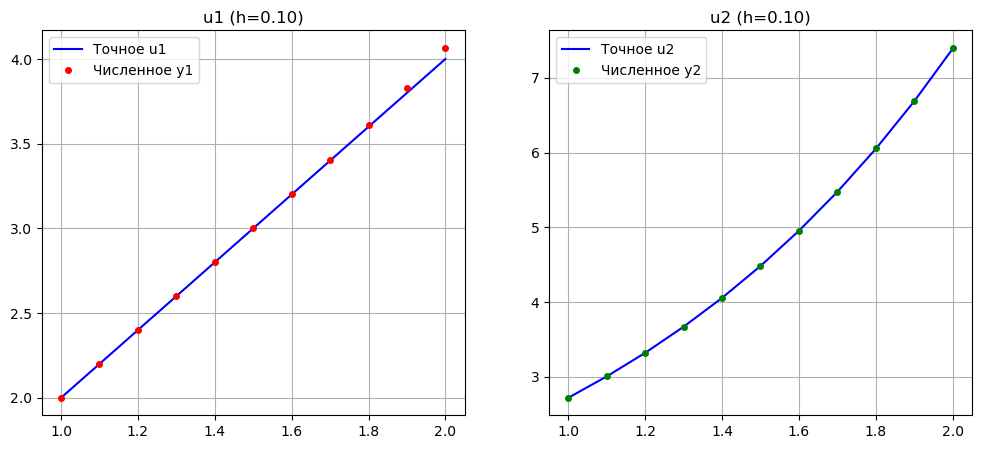

   20 | 0.050000 | 0.01302186 | 0.00288457
   40 | 0.025000 | 0.00307197 | 0.00069679
   80 | 0.012500 | 0.00074870 | 0.00017157
  160 | 0.006250 | 0.00018868 | 0.00004311
  320 | 0.003125 | 0.00004102 | 0.00000992

Требуемая точность достигнута при N = 320


In [6]:
while True:
    errors["d1"], errors["d2"] = 0, 0
    h = (b - a) / n_intervals
    
    solve_cauchy(a, b, n_intervals, y_start, FPR, custom_out)
    
    print(f"{n_intervals:5d} | {h:.6f} | {errors['d1']:.8f} | {errors['d2']:.8f}")
    
    # Графики для h = h1
    if is_first_run:
        plt.figure(figsize=(12, 5))
        # График u1
        plt.subplot(1, 2, 1)
        plt.plot(plot_data["x"], plot_data["u1"], 'b-', label='Точное u1')
        plt.plot(plot_data["x"], plot_data["y1"], 'ro', markersize=4, label='Численное y1')
        plt.title(f"u1 (h={h:.2f})")
        plt.grid(True); plt.legend()
        
        # График u2
        plt.subplot(1, 2, 2)
        plt.plot(plot_data["x"], plot_data["u2"], 'b-', label='Точное u2')
        plt.plot(plot_data["x"], plot_data["y2"], 'go', markersize=4, label='Численное y2')
        plt.title(f"u2 (h={h:.2f})")
        plt.grid(True); plt.legend()
        plt.show()
        is_first_run = False

    # Проверка достижения точности на конце отрезка
    if max(errors["d1"], errors["d2"]) < target_err:
        print(f"\nТребуемая точность достигнута при N = {n_intervals}")
        break
    
    n_intervals *= 2
    if n_intervals > 10000: break